In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
# Đọc dữ liệu từ file CSV
df = pd.read_csv("/content/kc_final.csv")

# Hiển thị 5 dòng đầu tiên
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
# Xem tên tất cả các cột
print(df.columns.tolist())

['Unnamed: 0', 'id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [ ]:
# Xem thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     21613 non-null  int64  
 1   id             21613 non-null  int64  
 2   date           21613 non-null  object 
 3   price          21613 non-null  float64
 4   bedrooms       21613 non-null  int64  
 5   bathrooms      21613 non-null  float64
 6   sqft_living    21613 non-null  int64  
 7   sqft_lot       21613 non-null  int64  
 8   floors         21613 non-null  float64
 9   waterfront     21613 non-null  int64  
 10  view           21613 non-null  int64  
 11  condition      21613 non-null  int64  
 12  grade          21613 non-null  int64  
 13  sqft_above     21613 non-null  int64  
 14  sqft_basement  21613 non-null  int64  
 15  yr_built       21613 non-null  int64  
 16  yr_renovated   21613 non-null  int64  
 17  zipcode        21613 non-null  int64  
 18  lat   

In [ ]:
# Kiểm tra số dòng bị trùng
print("Số dòng trùng lặp:", df.duplicated().sum())
# Kiểm tra thống kê cơ bản
df.describe()

Số dòng trùng lặp: 0


,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [ ]:
# Chọn 5 đặc trưng cơ bản
features = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'grade',
    'yr_built'
]

X = df[features]
y = df['price']

print("Các đặc trưng sử dụng:", features)
print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Các đặc trưng sử dụng: ['bedrooms', 'bathrooms', 'sqft_living', 'grade', 'yr_built']
Kích thước X: (21613, 5)
Kích thước y: (21613,)


In [ ]:
# Chia dữ liệu thành tập train và test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Số mẫu train:", len(X_train))
print("Số mẫu test:", len(X_test))

Số mẫu train: 17290
Số mẫu test: 4323


In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu.")
print("Kích thước X_train:", X_train_scaled.shape)
print("Kích thước X_test:", X_test_scaled.shape)

Đã chuẩn hóa dữ liệu.
Kích thước X_train: (17290, 5)
Kích thước X_test: (4323, 5)


In [ ]:
# Tạo 3 nhóm giá cho bài toán phân loại SVC

df['price_group'] = pd.qcut(
    df['price'],
    q=3,
    labels=['Thấp', 'Trung bình', 'Cao']
)

# Kiểm tra số lượng mẫu mỗi nhóm
print(df['price_group'].value_counts())

price_group
Thấp          7226
Trung bình    7223
Cao           7164
Name: count, dtype: int64


In [ ]:
# Tạo biến mục tiêu cho SVC
y_class = df['price_group']

# Kiểm tra nhãn
print("Các lớp:", y_class.unique())
print("\nSố lượng mỗi lớp:")
print(y_class.value_counts())

Các lớp: ['Thấp', 'Trung bình', 'Cao']
Categories (3, object): ['Thấp' < 'Trung bình' < 'Cao']

Số lượng mỗi lớp:
price_group
Thấp          7226
Trung bình    7223
Cao           7164
Name: count, dtype: int64


In [ ]:
# Chia dữ liệu cho bài toán phân loại SVC
X_train_svc, X_test_svc, y_train_svc, y_test_svc = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train:", X_train_svc.shape)
print("Test:", X_test_svc.shape)

Train: (17290, 5)
Test: (4323, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_svc = StandardScaler()

X_train_svc_scaled = scaler_svc.fit_transform(X_train_svc)
X_test_svc_scaled = scaler_svc.transform(X_test_svc)

print("Đã chuẩn hóa dữ liệu cho SVC.")
print("X_train:", X_train_svc_scaled.shape)
print("X_test:", X_test_svc_scaled.shape)

Đã chuẩn hóa dữ liệu cho SVC.
X_train: (17290, 5)
X_test: (4323, 5)


In [ ]:
svc_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

svc_model.fit(
    X_train_svc_scaled,
    y_train_svc
)

print("Đã train xong mô hình SVC!")

Đã train xong mô hình SVC!


In [ ]:
y_pred_svc = svc_model.predict(X_test_svc_scaled)

accuracy = accuracy_score(y_test_svc, y_pred_svc)

print("Accuracy của SVC:", accuracy)

Accuracy của SVC: 0.6365949572056442


In [ ]:
print(classification_report(y_test_svc, y_pred_svc))

              precision    recall  f1-score   support

         Cao       0.75      0.70      0.73      1433
        Thấp       0.68      0.71      0.69      1445
  Trung bình       0.49      0.50      0.49      1445

    accuracy                           0.64      4323
   macro avg       0.64      0.64      0.64      4323
weighted avg       0.64      0.64      0.64      4323



In [ ]:
cm = confusion_matrix(y_test_svc, y_pred_svc)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1003   43  387]
 [  50 1032  363]
 [ 276  452  717]]


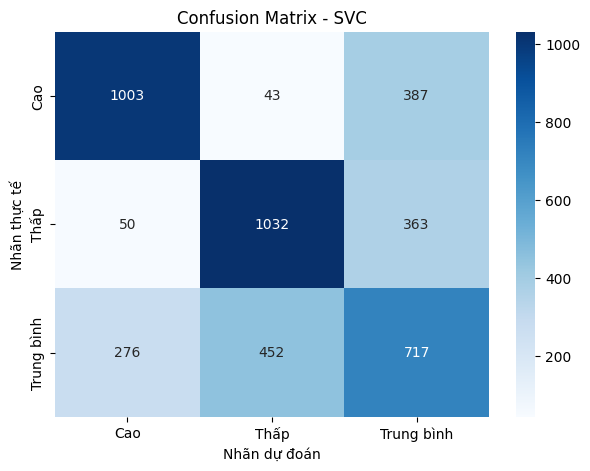

In [ ]:
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Cao', 'Thấp', 'Trung bình'],
    yticklabels=['Cao', 'Thấp', 'Trung bình']
)

plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực tế')
plt.title('Confusion Matrix - SVC')
plt.show()

In [ ]:
print("Biến mục tiêu SVR:", y.name)
print("Số mẫu:", len(y))
print("Giá nhà trung bình:", y.mean())

Biến mục tiêu SVR: price
Số mẫu: 21613
Giá nhà trung bình: 540088.1417665294


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_svr = StandardScaler()

X_train_svr_scaled = scaler_svr.fit_transform(X_train)
X_test_svr_scaled = scaler_svr.transform(X_test)

print("Đã chuẩn hóa dữ liệu cho SVR.")
print("X_train:", X_train_svr_scaled.shape)
print("X_test:", X_test_svr_scaled.shape)

Đã chuẩn hóa dữ liệu cho SVR.
X_train: (17290, 5)
X_test: (4323, 5)


In [ ]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_model.fit(
    X_train_svr_scaled,
    y_train
)

print("Đã train xong mô hình SVR!")

Đã train xong mô hình SVR!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_svr = svr_model.predict(X_test_svr_scaled)

mae = mean_absolute_error(y_test, y_pred_svr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2 = r2_score(y_test, y_pred_svr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 191544.89501326397
RMSE: 361860.23898994556
R²: 0.13384257001579536


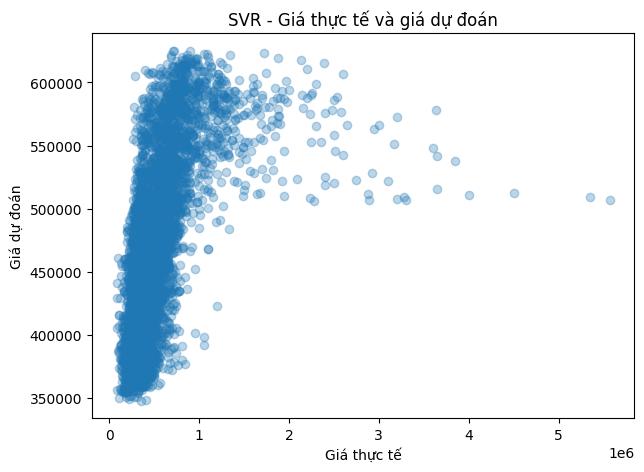

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_svr, alpha=0.3)

plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.title("SVR - Giá thực tế và giá dự đoán")

plt.show()

In [ ]:
import joblib

joblib.dump(svc_model, 'svc_model.pkl')
joblib.dump(svr_model, 'svr_model.pkl')

joblib.dump(scaler_svc, 'scaler_svc.pkl')
joblib.dump(scaler_svr, 'scaler_svr.pkl')

print("Đã lưu 4 file model và scaler!")

Đã lưu 4 file model và scaler!
